In [ ]:
import os

os.chdir("/content/drive/MyDrive/METCS767_Project_Assignment/300W")

os.getcwd()

'/content/drive/MyDrive/METCS767_Project_Assignment/300W'

In [ ]:
# TASK 2: FACE 14-KEYPOINT DETECTION ON 300W DATASET
# ResNet-18 + Landmark Regression on 256×256 Crops
# Install dependencies
!pip install -U retinaface-pytorch opencv-python-headless scikit-learn tqdm -q


# IMPORTS & SETUP

import os
import random
import glob
import numpy as np
from PIL import Image
import json
import time
from datetime import datetime

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from torchvision.transforms import functional as TF

from sklearn.model_selection import train_test_split
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import matplotlib.patches as patches



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 120.5 MB/s eta 0:00:00


In [ ]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
print(f"Seed: {SEED}")

if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

ROOT_300W = "/content/drive/MyDrive/METCS767_Project_Assignment/300W/300W"

Device: cuda
Seed: 42
GPU: NVIDIA L4
GPU Memory: 23.8 GB


In [ ]:
!sudo apt-get -y install p7zip-full
!7z x 300w.zip.001


Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
p7zip-full is already the newest version (16.02+dfsg-8).
0 upgraded, 0 newly installed, 0 to remove and 41 not upgraded.

7-Zip [64] 16.02 : Copyright (c) 1999-2016 Igor Pavlov : 2016-05-21
p7zip Version 16.02 (locale=en_US.UTF-8,Utf16=on,HugeFiles=on,64 bits,12 CPUs Intel(R) Xeon(R) CPU @ 2.20GHz (50657),ASM,AES-NI)

Scanning the drive for archives:
  0M Scan         1 file, 629145600 bytes (600 MiB)

Extracting archive: 300w.zip.001
  0% 1 Open           --
Path = 300w.zip.001
Type = Split
Physical Size = 629145600
Volumes = 4
Total Physical Size = 2138745671
----
Path = 300w.zip
Size = 2138745671
--
Path = 300w.zip
Type = zip
Physical Size = 2138745671

  0%    
Would you like to replace the existing file:
  Path:     ./300W/01_Indoor/indoor_001.png
  Size:     526811 bytes (515 KiB)
  Modified: 2025-12-04 22:08:32
with the file from archiv

In [ ]:
def parse_pts_file(pts_path):
    """
    Parse a 300W .pts file like the one you pasted.
    Returns (68, 2) float32 array.
    """
    coords = []
    with open(pts_path, "r") as f:
        in_points = False
        for line in f:
            line = line.strip()
            if line.startswith("{"):
                in_points = True
                continue
            if line.startswith("}"):
                break
            if not in_points:
                continue
            if not line:
                continue
            parts = line.split()
            if len(parts) < 2:
                continue
            x, y = float(parts[0]), float(parts[1])
            coords.append([x, y])
    if len(coords) != 68:
        raise ValueError(f"{pts_path}: expected 68 points, got {len(coords)}")
    return np.asarray(coords, dtype=np.float32)


def load_300w_samples(root_dir):
    """
    Walk all subfolders (01_Indoor, 02_Outdoor, etc.) and
    collect (image_path, landmarks_68) pairs.
    Assumes each `foo.png` has a matching `foo.pts`.
    """
    samples = []
    pts_files = glob.glob(os.path.join(root_dir, "**", "*.pts"), recursive=True)
    print("Found .pts files:", len(pts_files))

    for pts_path in tqdm(pts_files, desc="Parsing 300W .pts"):
        try:
            lm68 = parse_pts_file(pts_path)
        except Exception as e:
            print("  Skipping", pts_path, ":", e)
            continue

        base = os.path.splitext(pts_path)[0]
        img_path = base + ".png"
        if not os.path.exists(img_path):
            img_path = base + ".jpg"
        if not os.path.exists(img_path):
            print("  Image missing for", pts_path)
            continue

        samples.append((img_path, lm68))

    print("Total valid samples:", len(samples))
    return samples


samples_300w = load_300w_samples(ROOT_300W)


Found .pts files: 600


Parsing 300W .pts:   0%|          | 0/600 [00:00<?, ?it/s]

Total valid samples: 600


In [ ]:
# 6 right-eye, 6 left-eye, 8 inner-mouth points (standard 68‑landmark indexing)
RIGHT_EYE_IDX = list(range(36, 42))    # 36–41
LEFT_EYE_IDX  = list(range(42, 48))    # 42–47
MOUTH_INNER_IDX = list(range(60, 68))  # 60–67

SELECTED_IDX = RIGHT_EYE_IDX + LEFT_EYE_IDX + MOUTH_INNER_IDX  # length 20
NUM_KP = len(SELECTED_IDX)  # 20 keypoints → 40 coords
print("Num keypoints:", NUM_KP)


Num keypoints: 20


In [ ]:
class Keypoint300WDataset(Dataset):
    def __init__(self, samples, resize_size=256, expand_ratio=0.15,
                 selected_idx=None, transform=None):
        self.samples = samples
        self.resize_size = resize_size
        self.expand_ratio = expand_ratio
        self.selected_idx = selected_idx if selected_idx is not None else SELECTED_IDX

        if transform is None:
            self.transform = transforms.Compose([
                transforms.ToTensor(),
                transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                     std=[0.229, 0.224, 0.225]),
            ])
        else:
            self.transform = transform

    def __len__(self):
        return len(self.samples)

    def _bbox_from_landmarks(self, lm68):
        x_min = lm68[:, 0].min()
        y_min = lm68[:, 1].min()
        x_max = lm68[:, 0].max()
        y_max = lm68[:, 1].max()
        return x_min, y_min, x_max, y_max

    def __getitem__(self, idx):
        img_path, lm68 = self.samples[idx]
        img = Image.open(img_path).convert("RGB")
        W, H = img.size

        kp = lm68[self.selected_idx, :]  # (K,2)

        x1, y1, x2, y2 = self._bbox_from_landmarks(lm68)
        bw, bh = x2 - x1, y2 - y1
        cx, cy = x1 + bw / 2.0, y1 + bh / 2.0

        bw_e = bw * (1.0 + self.expand_ratio)
        bh_e = bh * (1.0 + self.expand_ratio)

        x1e = max(0.0, cx - bw_e / 2.0)
        y1e = max(0.0, cy - bh_e / 2.0)
        x2e = min(W - 1.0, cx + bw_e / 2.0)
        y2e = min(H - 1.0, cy + bh_e / 2.0)

        crop = img.crop((x1e, y1e, x2e, y2e))
        crop = crop.resize((self.resize_size, self.resize_size), Image.BILINEAR)

        cw, ch = x2e - x1e, y2e - y1e
        kp_norm = kp.copy()
        kp_norm[:, 0] = (kp_norm[:, 0] - x1e) / max(cw, 1e-6)
        kp_norm[:, 1] = (kp_norm[:, 1] - y1e) / max(ch, 1e-6)
        kp_norm = np.clip(kp_norm, 0.0, 1.0)

        img_t = self.transform(crop)
        kp_t = torch.from_numpy(kp_norm.reshape(-1)).float()
        return img_t, kp_t

In [ ]:
class KeypointResNet18(nn.Module):
    def __init__(self, num_keypoints=NUM_KP, dropout=0.3):
        super().__init__()
        self.backbone = models.resnet18(
            weights=models.ResNet18_Weights.IMAGENET1K_V1
        )
        in_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Sequential(
            nn.Linear(in_features, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(512, num_keypoints * 2),
        )

    def forward(self, x):
        return self.backbone(x)


NameError: name 'nn' is not defined

In [ ]:
class KeypointResNet18WithConf(nn.Module):
    def __init__(self, num_keypoints=20, dropout=0.3):  # Keep 20
        super().__init__()
        self.num_keypoints = num_keypoints
        self.backbone = models.resnet18(
            weights=models.ResNet18_Weights.IMAGENET1K_V1
        )
        in_features = self.backbone.fc.in_features
        # Output: x, y, confidence for each keypoint
        self.backbone.fc = nn.Sequential(
            nn.Linear(in_features, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(512, num_keypoints * 3),  # 20*3 = 60 outputs
        )

    def forward(self, x):
        out = self.backbone(x)
        out = out.view(-1, self.num_keypoints, 3)  # (B, 20, 3)
        xy = torch.sigmoid(out[..., :2])            # normalize x,y to [0,1]
        c  = torch.sigmoid(out[..., 2:3])           # normalize confidence to [0,1]
        return torch.cat([xy, c], dim=-1)           # (B, 20, 3)



RIGHT_EYE_IDX = list(range(36, 42))
LEFT_EYE_IDX = list(range(42, 48))
MOUTH_INNER_IDX = list(range(60, 68))
SELECTED_IDX = RIGHT_EYE_IDX + LEFT_EYE_IDX + MOUTH_INNER_IDX
NUM_KP = len(SELECTED_IDX)
print("Num keypoints:", NUM_KP)

model = KeypointResNet18WithConf(num_keypoints=NUM_KP).to(device)
print(sum(p.numel() for p in model.parameters())/1e6, "M parameters")



Num keypoints: 20
11.469948 M parameters


In [ ]:
# split
train_samples, val_samples = train_test_split(
    samples_300w, test_size=0.2, random_state=SEED, shuffle=True
)
print("Train:", len(train_samples), "Val:", len(val_samples))

Train: 480 Val: 120


In [ ]:
import torch.nn.functional as F

def keypoint_loss_with_conf(preds, targets, num_keypoints=20, lambda_conf=0.1):
    """
    preds: (B, 20, 3) → [x, y, c]
    targets: (B, 20*2) → flattened GT xy (normalized)
    lambda_conf: weight for confidence loss
    """
    B, K = preds.size(0), num_keypoints

    # Extract predictions
    pred_xy = preds[..., :2].reshape(B, K*2)  # (B, 40)
    pred_c  = preds[..., 2]                   # (B, 20)

    # GT coordinates
    gt_xy = targets  # (B, 40)

    # 1. Coordinate MSE loss
    mse_xy = F.mse_loss(pred_xy, gt_xy)

    # 2. Confidence target: high when error is small
    with torch.no_grad():
        # Per-keypoint L2 error
        per_kp_err = (pred_xy - gt_xy).reshape(B, K, 2).pow(2).sum(dim=-1).sqrt()  # (B, K)
        # Target confidence: exp(-error), closer to 1 when error small
        conf_target = torch.exp(-per_kp_err)  # (B, K)

    # Confidence MSE loss
    mse_conf = F.mse_loss(pred_c, conf_target)

    # Total loss
    total_loss = mse_xy + lambda_conf * mse_conf
    return total_loss


In [ ]:
train_ds = Keypoint300WDataset(train_samples)
val_ds   = Keypoint300WDataset(val_samples)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True, num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_ds, batch_size=32, shuffle=False, num_workers=0, pin_memory=True)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

train_losses = []
val_losses = []

def run_epoch(loader, train=True):
    model.train() if train else model.eval()
    total_loss, n = 0.0, 0
    for imgs, kps in tqdm(loader, leave=False):
        imgs, kps = imgs.to(device), kps.to(device)
        with torch.set_grad_enabled(train):
            preds = model(imgs)  # (B, 20, 3)
            loss = keypoint_loss_with_conf(preds, kps, num_keypoints=NUM_KP, lambda_conf=0.1)
            if train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
        total_loss += loss.item() * imgs.size(0)
        n += imgs.size(0)
    return total_loss / n

best_val = float("inf")
ckpt = "/content/drive/MyDrive/METCS767_Project_Assignment/checkpoints/task2_20kp_conf_best.pth"
os.makedirs(os.path.dirname(ckpt), exist_ok=True)

for epoch in range(1, 31):
    train_loss = run_epoch(train_loader, train=True)
    val_loss   = run_epoch(val_loader, train=False)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    scheduler.step()
    print(f"Epoch {epoch:02d} | train {train_loss:.4f} | val {val_loss:.4f}")
    if val_loss < best_val:
        best_val = val_loss
        torch.save(model.state_dict(), ckpt)
        print("  saved best")

print("Best val loss:", best_val)




  0%|          | 0/15 [00:00<?, ?it/s]

  0%|          | 0/4 [00:00<?, ?it/s]

Epoch 01 | train 0.0157 | val 0.0286
  saved best


  0%|          | 0/15 [00:00<?, ?it/s]

  0%|          | 0/4 [00:00<?, ?it/s]

...

  0%|          | 0/4 [00:00<?, ?it/s]

Epoch 29 | train 0.0008 | val 0.0007


  0%|          | 0/15 [00:00<?, ?it/s]

  0%|          | 0/4 [00:00<?, ?it/s]

Epoch 30 | train 0.0009 | val 0.0008
Best val loss: 0.0007050761758970718


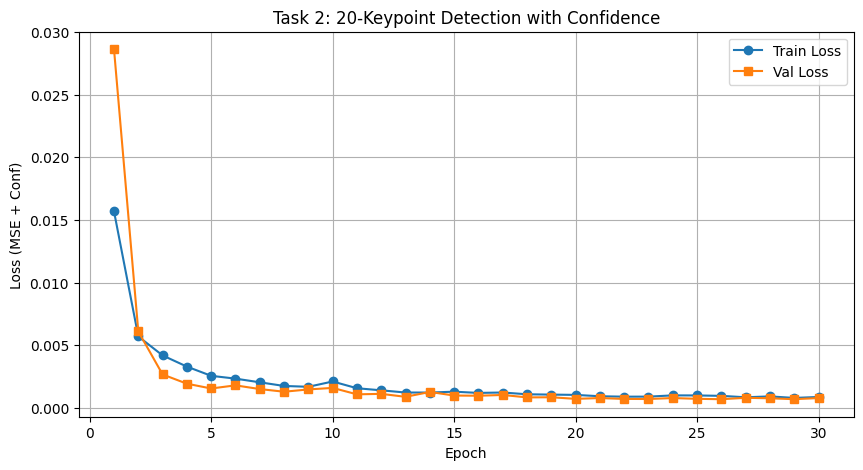

✓ Loss curve saved


In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(range(1, len(train_losses)+1), train_losses, label='Train Loss', marker='o')
plt.plot(range(1, len(val_losses)+1), val_losses, label='Val Loss', marker='s')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE + Conf)')
plt.title('Task 2: 20-Keypoint Detection with Confidence')
plt.legend()
plt.grid(True)
plt.savefig('/content/drive/MyDrive/METCS767_Project_Assignment/task2_loss_curves_20kp_conf.png', dpi=150, bbox_inches='tight')
plt.show()
print("Loss curve saved")


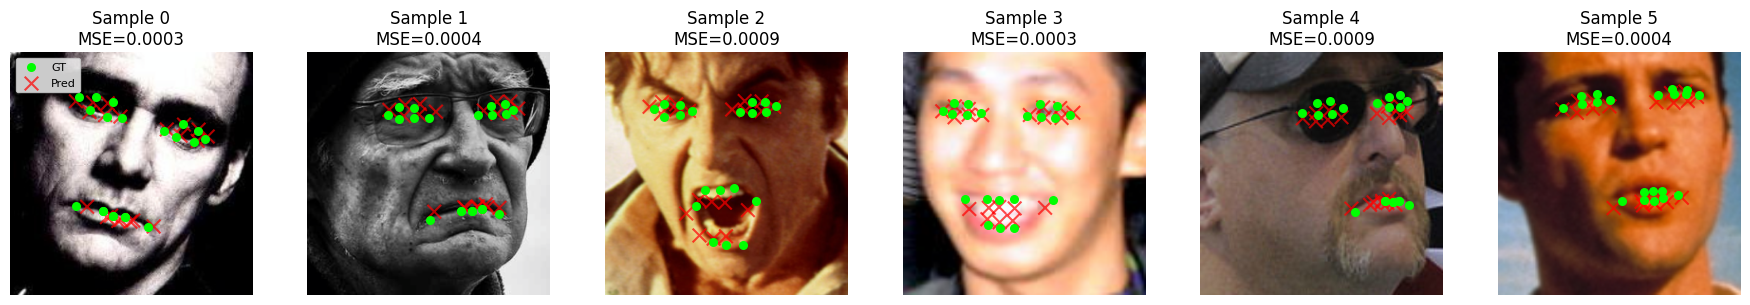

Predictions with confidence visualized and saved


In [ ]:
# Load best model
ckpt = "/content/drive/MyDrive/METCS767_Project_Assignment/checkpoints/task2_20kp_conf_best.pth" # Corrected path
model_vis = KeypointResNet18WithConf(num_keypoints=NUM_KP).to(device)
model_vis.load_state_dict(torch.load(ckpt, map_location=device))
model_vis.eval()

def denorm(img_t):
    mean = np.array([0.485, 0.456, 0.406]).reshape(3,1,1)
    std  = np.array([0.229, 0.224, 0.225]).reshape(3,1,1)
    img = img_t.cpu().numpy()
    img = img * std + mean
    img = np.clip(img, 0.0, 1.0)
    img = np.transpose(img, (1,2,0))
    return img

# Visualize N samples with confidence
N = 6
fig, axes = plt.subplots(1, N, figsize=(3*N, 3))
if N == 1:
    axes = [axes]

for i in range(N):
    idx = np.random.randint(0, len(val_ds))
    img_t, kp_t = val_ds[idx]
    img_np = denorm(img_t)

    kp_gt = kp_t.numpy().reshape(-1, 2)  # (20, 2)

    with torch.no_grad():
        pred = model_vis(img_t.unsqueeze(0).to(device))  # (1, 20, 3)

    pred_np = pred[0].cpu().numpy()  # (20, 3)
    kp_pred = pred_np[:, :2]  # (20, 2)
    conf_pred = pred_np[:, 2]  # (20,)

    mse = ((kp_pred - kp_gt) ** 2).mean()

    ax = axes[i]
    ax.imshow(img_np)

    # GT points (green)
    ax.scatter(kp_gt[:,0]*256, kp_gt[:,1]*256, c='lime', s=30, label='GT', zorder=5)

    # Predicted points (red) with size proportional to confidence
    sizes = conf_pred * 100  # scale for visibility
    ax.scatter(kp_pred[:,0]*256, kp_pred[:,1]*256, c='red', s=sizes, marker='x',
               label='Pred', alpha=0.7, zorder=4)

    ax.set_title(f"Sample {i}\nMSE={mse:.4f}")
    ax.axis("off")
    if i == 0:
        ax.legend(fontsize=8, loc="upper left")

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/METCS767_Project_Assignment/task2_predictions_20kp_conf.png', dpi=150, bbox_inches='tight')
plt.show()

print("Predictions with confidence visualized and saved")


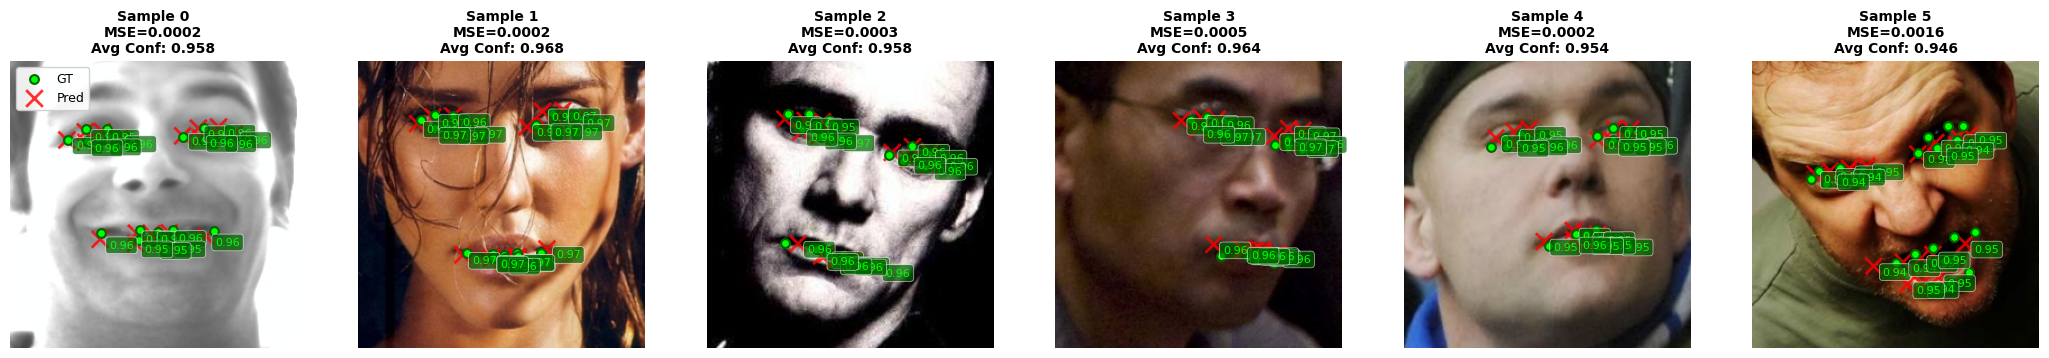

Saved predictions with EXPLICIT confidence values


In [ ]:
# TASK 2: DETAILED VISUALIZATION WITH CONFIDENCE VALUES

# Load best model
model_vis = KeypointResNet18WithConf(num_keypoints=NUM_KP).to(device)
model_vis.load_state_dict(torch.load(ckpt, map_location=device))
model_vis.eval()

def denorm(img_t):
    mean = np.array([0.485, 0.456, 0.406]).reshape(3,1,1)
    std  = np.array([0.229, 0.224, 0.225]).reshape(3,1,1)
    img = img_t.cpu().numpy()
    img = img * std + mean
    img = np.clip(img, 0.0, 1.0)
    img = np.transpose(img, (1,2,0))
    return img

# Visualize with EXPLICIT CONFIDENCE VALUES
N = 6
fig, axes = plt.subplots(1, N, figsize=(3.5*N, 3.5))
if N == 1:
    axes = [axes]

for i in range(N):
    idx = np.random.randint(0, len(val_ds))
    img_t, kp_t = val_ds[idx]
    img_np = denorm(img_t)

    kp_gt = kp_t.numpy().reshape(-1, 2)  # (20, 2)

    with torch.no_grad():
        pred = model_vis(img_t.unsqueeze(0).to(device))  # (1, 20, 3)

    pred_np = pred[0].cpu().numpy()  # (20, 3)
    kp_pred = pred_np[:, :2]  # (20, 2)
    conf_pred = pred_np[:, 2]  # (20,)

    mse = ((kp_pred - kp_gt) ** 2).mean()

    ax = axes[i]
    ax.imshow(img_np)

    # GT points (green circles)
    ax.scatter(kp_gt[:,0]*256, kp_gt[:,1]*256, c='lime', s=40, marker='o',
               label='GT', zorder=5, edgecolors='darkgreen', linewidth=1.5)

    # Predicted points (red X) with size proportional to confidence
    sizes = conf_pred * 150  # scale for visibility
    ax.scatter(kp_pred[:,0]*256, kp_pred[:,1]*256, c='red', s=sizes, marker='x',
               label='Pred', alpha=0.8, zorder=4, linewidth=2)

    # Add confidence text labels for ALL points (color-coded by confidence)
    for j, (x, y, c) in enumerate(zip(kp_pred[:,0]*256, kp_pred[:,1]*256, conf_pred)):
        # Color text based on confidence: green (high), yellow (med), red (low)
        if c > 0.7:
            text_color = 'lime'
            bg_color = 'darkgreen'
        elif c > 0.4:
            text_color = 'yellow'
            bg_color = 'orange'
        else:
            text_color = 'white'
            bg_color = 'darkred'


        ax.text(x+8, y+8, f'{c:.2f}', fontsize=8, color=text_color,
               bbox=dict(boxstyle='round,pad=0.3', facecolor=bg_color, alpha=0.7, edgecolor='white', linewidth=0.5),
               zorder=10)

    ax.set_title(f"Sample {i}\nMSE={mse:.4f}\nAvg Conf: {np.mean(conf_pred):.3f}", fontsize=10, fontweight='bold')
    ax.axis("off")
    if i == 0:
        ax.legend(fontsize=9, loc="upper left", framealpha=0.9)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/METCS767_Project_Assignment/task2_predictions_20kp_conf_explicit.png', dpi=200, bbox_inches='tight')
plt.show()

print("Saved predictions with EXPLICIT confidence values")
